In [1]:
import pandas as pd
import glob
import os
import scanpy as sc
from cellphonedb.utils import db_utils
import anndata
from cellphonedb.src.core.methods import cpdb_statistical_analysis_method
counts_file_path = '/nfs/team298/ls34/adult_skin/cellphonedb/input_files/normalised_log_counts_all_eosfib2.h5ad'
adata = anndata.read_h5ad(counts_file_path)
adata.shape
sc.settings.set_figure_params(dpi_save=300, dpi=300, facecolor="white", frameon=False, figsize=(20,20))
pd.set_option('display.max_columns', 100)
from IPython.display import HTML, display
from cellphonedb.utils import db_releases_utils

display(HTML(db_releases_utils.get_remote_database_versions_html()['db_releases_html_table']))

In [2]:
#sc.settings.figdir = "fig5"


# Uncomment to run CCC

In [3]:
cpdb_version = 'v5.0.0'
cpdb_target_dir = os.path.join('/nfs/team298/ls34/adult_skin/cellphonedb/', cpdb_version)

In [4]:
db_utils.download_database(cpdb_target_dir, cpdb_version)
cpdb_input_dir = '/nfs/team298/ls34/adult_skin/cellphonedb/v5.0.0/'
db_utils.create_db(cpdb_input_dir)

Downloaded cellphonedb.zip into /nfs/team298/ls34/adult_skin/cellphonedb/v5.0.0
Downloaded complex_input.csv into /nfs/team298/ls34/adult_skin/cellphonedb/v5.0.0
Downloaded gene_input.csv into /nfs/team298/ls34/adult_skin/cellphonedb/v5.0.0
Downloaded interaction_input.csv into /nfs/team298/ls34/adult_skin/cellphonedb/v5.0.0
Downloaded protein_input.csv into /nfs/team298/ls34/adult_skin/cellphonedb/v5.0.0
Downloaded uniprot_synonyms.tsv into /nfs/team298/ls34/adult_skin/cellphonedb/v5.0.0/sources
Downloaded transcription_factor_input.csv into /nfs/team298/ls34/adult_skin/cellphonedb/v5.0.0/sources

Created /nfs/team298/ls34/adult_skin/cellphonedb/v5.0.0/cellphonedb_11_29_2025_153946.zip successfully


In [5]:
cpdb_file_path = os.path.join(cpdb_target_dir, 'cellphonedb.zip')
cpdb_file_path




'/nfs/team298/ls34/adult_skin/cellphonedb/v5.0.0/cellphonedb.zip'

In [6]:
meta_file_path = '/nfs/team298/ls34/adult_skin/cellphonedb/input_files/metadata_all_eosfib2.tsv'
out_path = '/nfs/team298/ls34/adult_skin/cellphonedb/v5.0.0/results/method2_withScore/eos/'


In [7]:
metadata = pd.read_csv(meta_file_path, sep = '\t')
metadata.head(3)

,barcode_sample,cell_type
0,ACGGCCATCTGCTGTC_E2,Mac_TREM2+LPL+
1,AGCTCTCTCTAACTTC_E2,F3: FRC-like
2,CACACTCGTGGTAACG_E2,Pericyte1


In [8]:
metadata.cell_type.value_counts()

cell_type
F1: Superficial                   10641
F3: FRC-like                       5470
F2/3: Perivascular                 4565
Pericyte1                          3654
F5: NGFR+                           579
F6: Inflammatory myofibroblast      214
Mac_TREM2+LPL+                       32
Eosinophil                           20
Name: count, dtype: int64

In [9]:
# list(adata.obs.index).sort() == list(metadata['barcode_sample']).sort()


In [10]:
cpdb_results = cpdb_statistical_analysis_method.call(
    cpdb_file_path = cpdb_file_path,                 # mandatory: CellphoneDB database zip file.
    meta_file_path = meta_file_path,                 # mandatory: tsv file defining barcodes to cell label.
    counts_file_path = counts_file_path,             # mandatory: normalized count matrix - a path to the counts file, or an in-memory AnnData object
    counts_data = 'hgnc_symbol',                     # defines the gene annotation in counts matrix.
    #active_tfs_file_path = active_tf_path,           # optional: defines cell types and their active TFs.
    #microenvs_file_path = microenvs_file_path,       # optional (default: None): defines cells per microenvironment.
    score_interactions = True,                       # optional: whether to score interactions or not. 
    iterations = 1000,                               # denotes the number of shufflings performed in the analysis.
    threshold = 0.1,                                 # defines the min % of cells expressing a gene for this to be employed in the analysis.
    threads = 5,                                     # number of threads to use in the analysis.
    debug_seed = 42,                                 # debug randome seed. To disable >=0.
    result_precision = 3,                            # Sets the rounding for the mean values in significan_means.
    pvalue = 0.05,                                   # P-value threshold to employ for significance.
    subsampling = False,                             # To enable subsampling the data (geometri sketching).
    subsampling_log = False,                         # (mandatory) enable subsampling log1p for non log-transformed data inputs.
    subsampling_num_pc = 100,                        # Number of componets to subsample via geometric skectching (dafault: 100).
    subsampling_num_cells = 1000,                    # Number of cells to subsample (integer) (default: 1/3 of the dataset).
    separator = '|',                                 # Sets the string to employ to separate cells in the results dataframes "cellA|CellB".
    debug = False,                                   # Saves all intermediate tables employed during the analysis in pkl format.
    output_path = out_path,                          # Path to save results.
    output_suffix = None                             # Replaces the timestamp in the output files by a user defined string in the  (default: None).
    )

Reading user files...
The following user files were loaded successfully:
/nfs/team298/ls34/adult_skin/cellphonedb/input_files/normalised_log_counts_all_eosfib2.h5ad
/nfs/team298/ls34/adult_skin/cellphonedb/input_files/metadata_all_eosfib2.tsv
[ ][CORE][29/11/25-15:40:05][INFO] [Cluster Statistical Analysis] Threshold:0.1 Iterations:1000 Debug-seed:42 Threads:5 Precision:3
[ ][CORE][29/11/25-15:40:05][WARNING] Debug random seed enabled. Set to 42
[ ][CORE][29/11/25-15:40:09][INFO] Running Real Analysis
[ ][CORE][29/11/25-15:40:09][INFO] Running Statistical Analysis


100%|██████████| 1000/1000 [14:01<00:00,  1.19it/s]

[ ][CORE][29/11/25-15:54:12][INFO] Building Pvalues result


[ ][CORE][29/11/25-15:54:12][INFO] Building results
[ ][CORE][29/11/25-15:54:12][INFO] Scoring interactions: Filtering genes per cell type..


100%|██████████| 8/8 [00:00<00:00, 20.14it/s]

[ ][CORE][29/11/25-15:54:12][INFO] Scoring interactions: Calculating mean expression of each gene per group/cell type..



100%|██████████| 8/8 [00:00<00:00, 89.30it/s]


[ ][CORE][29/11/25-15:54:13][INFO] Scoring interactions: Calculating scores for all interactions and cell types..


100%|██████████| 64/64 [01:09<00:00,  1.09s/it]


Saved deconvoluted to /nfs/team298/ls34/adult_skin/cellphonedb/v5.0.0/results/method2_withScore/eos/statistical_analysis_deconvoluted_11_29_2025_155523.txt
Saved deconvoluted_percents to /nfs/team298/ls34/adult_skin/cellphonedb/v5.0.0/results/method2_withScore/eos/statistical_analysis_deconvoluted_percents_11_29_2025_155523.txt
Saved means to /nfs/team298/ls34/adult_skin/cellphonedb/v5.0.0/results/method2_withScore/eos/statistical_analysis_means_11_29_2025_155523.txt
Saved pvalues to /nfs/team298/ls34/adult_skin/cellphonedb/v5.0.0/results/method2_withScore/eos/statistical_analysis_pvalues_11_29_2025_155523.txt
Saved significant_means to /nfs/team298/ls34/adult_skin/cellphonedb/v5.0.0/results/method2_withScore/eos/statistical_analysis_significant_means_11_29_2025_155523.txt
Saved interaction_scores to /nfs/team298/ls34/adult_skin/cellphonedb/v5.0.0/results/method2_withScore/eos/statistical_analysis_interaction_scores_11_29_2025_155523.txt


# analysis

In [11]:
import anndata as ad
import pandas as pd
import ktplotspy as kpy
import matplotlib.pyplot as plt
%matplotlib inline

In [25]:
import os
BASE = '/nfs/team298/ls34/adult_skin/cellphonedb/v5.0.0/results/method2_withScore/eos/'
os.listdir(BASE)

['statistical_analysis_means_11_29_2025_134705.txt',
 'statistical_analysis_significant_means_11_29_2025_155523.txt',
 'statistical_analysis_pvalues_11_29_2025_134705.txt',
 'statistical_analysis_interaction_scores_11_29_2025_155523.txt',
 'statistical_analysis_means_11_29_2025_152848.txt',
 'statistical_analysis_deconvoluted_11_29_2025_155523.txt',
 'statistical_analysis_deconvoluted_11_29_2025_134705.txt',
 'statistical_analysis_pvalues_11_29_2025_155523.txt',
 'statistical_analysis_deconvoluted_percents_11_29_2025_134705.txt',
 'statistical_analysis_pvalues_11_29_2025_152848.txt',
 'statistical_analysis_interaction_scores_11_29_2025_134705.txt',
 'statistical_analysis_deconvoluted_11_29_2025_152848.txt',
 'statistical_analysis_deconvoluted_percents_11_29_2025_152848.txt',
 'statistical_analysis_means_11_29_2025_155523.txt',
 'statistical_analysis_significant_means_11_29_2025_134705.txt',
 'statistical_analysis_deconvoluted_percents_11_29_2025_155523.txt',
 'statistical_analysis_inte

In [26]:
[x for x in os.listdir(BASE) if '11_29_2025_1555' in x]

['statistical_analysis_significant_means_11_29_2025_155523.txt',
 'statistical_analysis_interaction_scores_11_29_2025_155523.txt',
 'statistical_analysis_deconvoluted_11_29_2025_155523.txt',
 'statistical_analysis_pvalues_11_29_2025_155523.txt',
 'statistical_analysis_means_11_29_2025_155523.txt',
 'statistical_analysis_deconvoluted_percents_11_29_2025_155523.txt']

In [14]:
# cpdb_results.results

In [15]:
try:
    decon=cpdb_results['deconvoluted']
    deconv=cpdb_results['deconvoluted']
    means = cpdb_results['means']
    pvals = cpdb_results['pvalues']
    interaction_scores=cpdb_results['interaction_scores']
    print("instantantiated")
except:
    TIME = '11_29_2025_155523'
    print("not loaded")
    decon = pd.read_csv(BASE + f'statistical_analysis_deconvoluted_{TIME}.txt', sep="\t")
    deconv=decon
    means = pd.read_csv(BASE +  f'statistical_analysis_means_{TIME}.txt', sep="\t")
    pvals = pd.read_csv(BASE + f'statistical_analysis_pvalues_{TIME}.txt', sep="\t")
    interaction_scores=pd.read_csv(BASE +  f'statistical_analysis_interaction_scores_{TIME}.txt', sep="\t")
#     import anndata
#     counts_file_path = '/nfs/team298/ls34/wound/cellphonedb/input_files/normalised_log_counts.h5ad'
#     adata = anndata.read_h5ad(counts_file_path)
#     adata.shape
    


instantantiated


In [16]:
try:
    kpy.plot_cpdb_heatmap(pvals = pvals,
                      degs_analysis = False,
                      figsize = (20,20),
                      title = "Sum of significant interactions")
except:
    print('fail')

In [17]:

# kpy.plot_cpdb_heatmap(
#     pvals=pvals, cell_types=["MigDC", "Tnaive/Tcm",], figsize=(4, 4), title="Sum of significant interactions"
# )

In [18]:
# choose cells with CCL26 expression
KEEP = ["Pericyte1","Mac_TREM2+LPL+","F6: Inflammatory myofibroblast","F3: FRC-like","F2/3: Perivascular","F1: Superficial","F4: TNN+COCH","F5: NGFR+"]
KEEP = [x for x in adata.obs["lvl5_annotation"].unique() if x in KEEP]
KEEP =  "|".join(KEEP)
KEEP

'Mac_TREM2+LPL+|F3: FRC-like|Pericyte1|F2/3: Perivascular|F5: NGFR+|F1: Superficial|F6: Inflammatory myofibroblast'

In [19]:
KEEP

'Mac_TREM2+LPL+|F3: FRC-like|Pericyte1|F2/3: Perivascular|F5: NGFR+|F1: Superficial|F6: Inflammatory myofibroblast'

In [20]:
from cellphonedb.utils import search_utils
 
search_results = search_utils.search_analysis_results(
    query_cell_types_1 = ['Eosinophil', ],  # List of cells 1, will be paired to cells 2 (list or 'All').
    query_cell_types_2 =  KEEP,    # List of cells 2, will be paired to cells 1 (list or 'All').
      query_genes = ["CCR3", "IL4", "OSM" 
    ],                                       # filter interactions based on the genes participating (list).
 #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
    significant_means = means,          # significant_means file generated by CellphoneDB.
    deconvoluted = deconv,                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = interaction_scores,        # interaction score generated by CellphoneDB.
    query_minimum_score = 100,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
   # query_classifications = ['Signaling by Transforming growth factor']
)

search_results.tail(50)



,interacting_pair,partner_a,partner_b,gene_a,gene_b,directionality,classification,interacting_cells,significant_mean


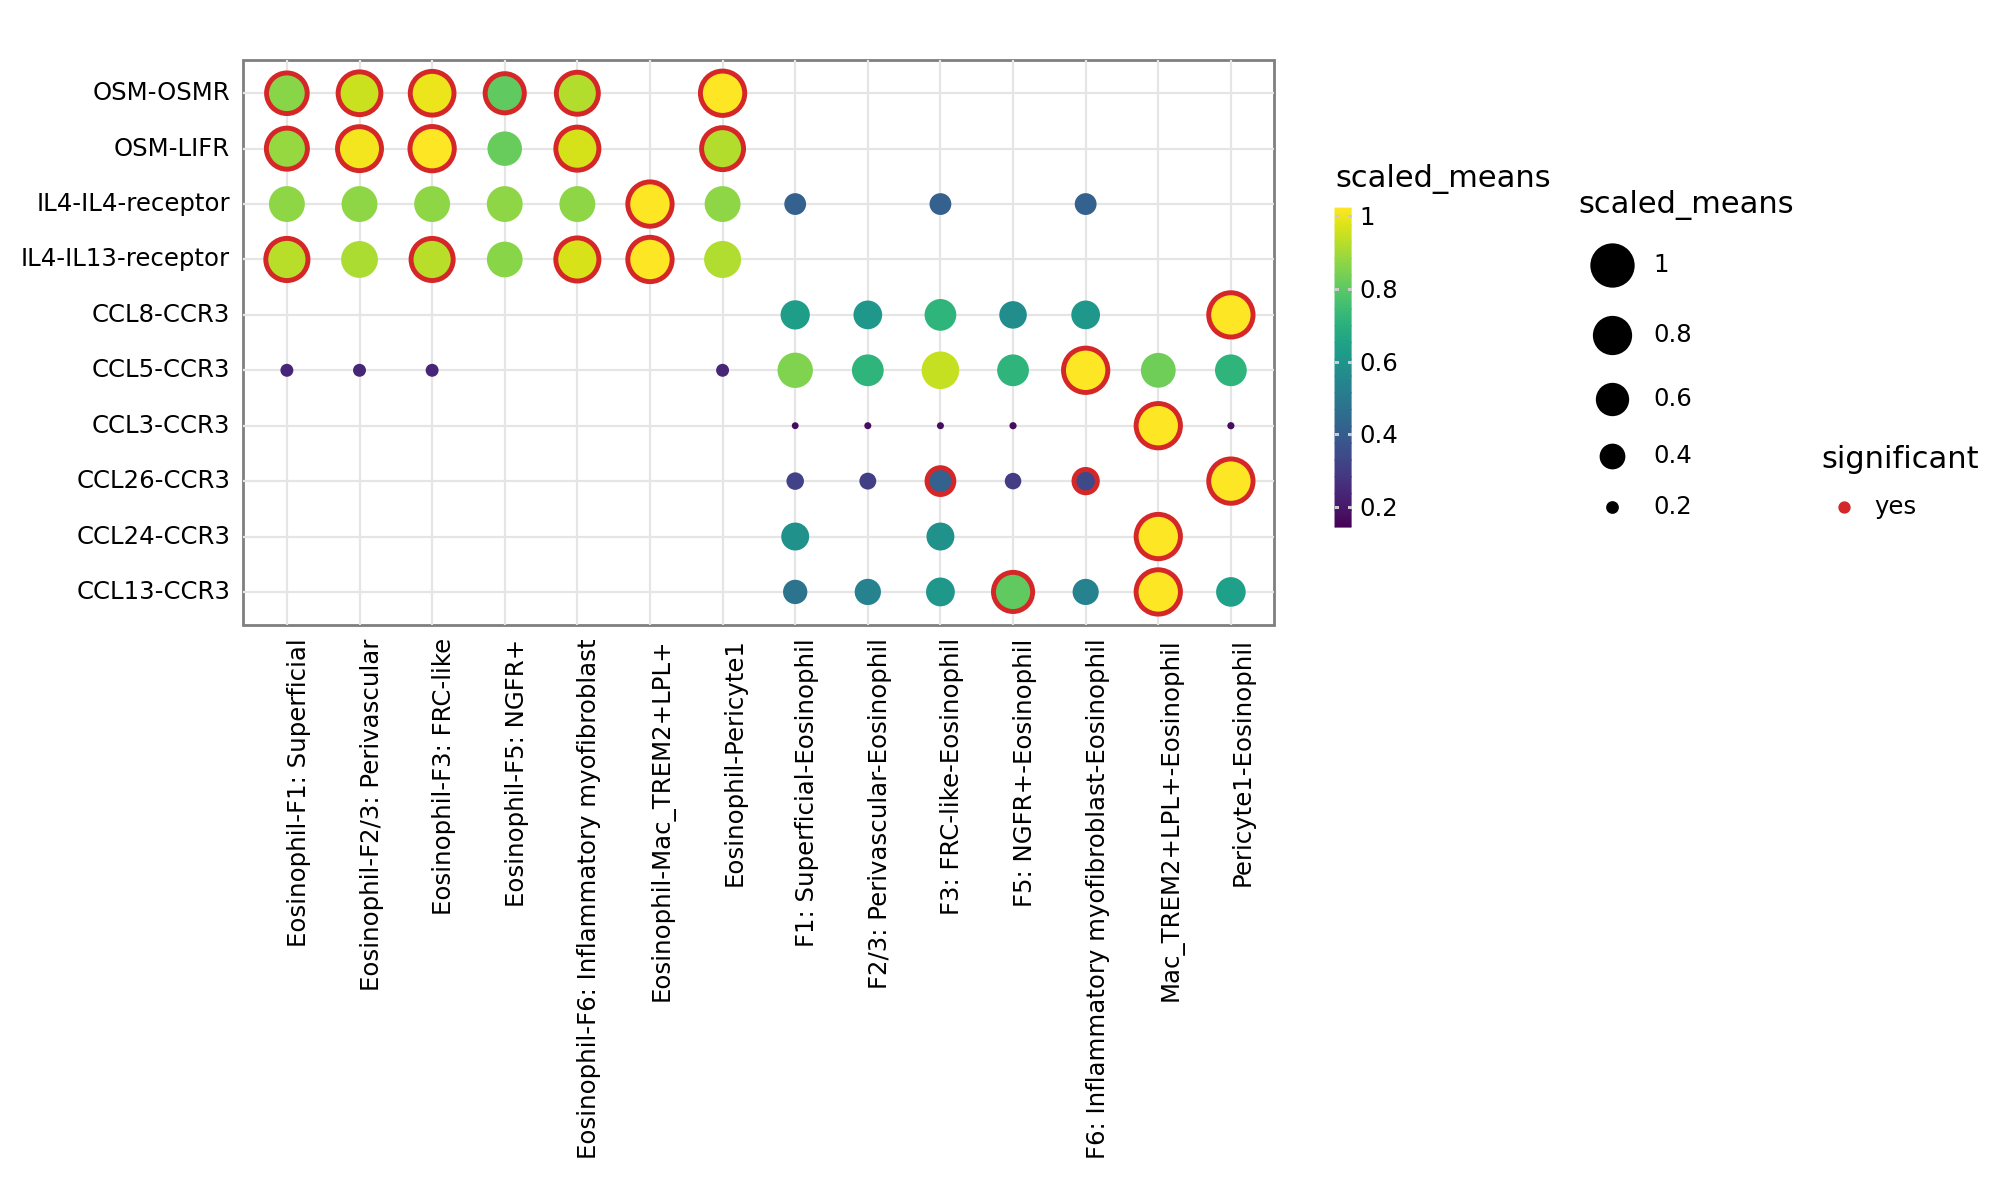

<Figure Size: (1000 x 600)>

In [24]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="Eosinophil",
    cell_type2= KEEP,
     genes = [  "CCR3", "IL4", "OSM"],
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(10, 6),
)

